#### FINM2013 Time Series for Finance and Macroeconomics

## Project 


**Due date of report: 11:59pm on 25 May 2024**

Each group will conduct the specific time series analysis and write an about 5-10-page substantial term paper on their own. You should write the results in a way that is easy-to-read, and interpret your findings clearly. In your paper, you must report the data sources clearly.

You should select a topic of your interest, collect the data by yourselves, and construct an adequate ARIMA model, and forecast future values based on the built model. Your time series analysis should follow the procedures taught in class.  

Use JupyterHub to write your report and submit it. R code must be included in your report. 

---

# <center>Analysis and Forecasting of Gold Price Trends using Time Series ARIMA Model</center>

<center> Wanni Hu  2130018019,
Ziwei Ai  2130018001,
Huixuan Meng  2130018043</center>

## 1. Introduction

### 1.1 Research background

Gold is one of the most closely watched investment products in the financial investment sector and has been an important precious metal since ancient times. Its price fluctuations are influenced by various factors, including the global economy, politics, and financial markets. In today's financial markets, gold is not only a raw material for jewelry and industrial use but also a crucial asset for investors to hedge against risks and preserve value. The fluctuation of gold prices reflects not only the supply and demand relationship in the market but also investors' views on the global economic situation and future expectations. Therefore, accurately analyzing and predicting gold price fluctuations is of significant importance to investors, economists, and policymakers.

Investors commonly use gold to counteract inflation and as a safe haven investment, making it highly valuable to study the price trends and characteristics of gold. For decades, inflation has been a major concern globally, with currency values depreciating and purchasing power diminishing, causing money to lose its value. However, gold, as a precious commodity, tends to appreciate with inflation, thus offsetting the losses caused by inflation and ensuring that investors' assets are not eroded by it. For these reasons, gold is seen as an ideal investment to combat inflation and is also suitable as a research subject for short-term time series forecasting.

### 1.2 Research purpose

The primary purpose of this study is to explore the fluctuation patterns of gold prices using time series analysis methods and to construct effective prediction models. The specific objectives include:

1. **Analyzing historical gold price data**: To investigate and reveal long-term price fluctuation trends.
2. **Applying time series analysis techniques**: To model gold prices using the Autoregressive Integrated Moving Average (ARIMA) model.
3. **Model diagnostics**: Determine the final structure of the model through multiple tests
4. **Forecasting future gold prices**: To provide data support for investment decisions by predicting gold prices for future periods.
5. **Discussing the limitations and improvement directions of the prediction models**: To explore potential improvements for future research by reflecting on the shortcomings of the existing models.

### 1.3 Brief introduction of time series analysis

Time series analysis is a statistical method used to analyze and predict data arranged in chronological order by establishing mathematical models. Common methods include Moving Average (MA), Autoregressive (AR) models, Autoregressive Moving Average (ARMA) models, and Autoregressive Integrated Moving Average (ARIMA) models and so on. These methods are suitable for different types of time series data and can be used to forecast stock prices, economic indicators, weather data, and other data with significant theoretical and practical application value due to their time-related characteristics.This study mainly uses ARIMA model to establish time series model and forecast the future gold price of Chinese spot gold.

---

## 2. Data processing and analysis

#### Import the necessary libraries

In [40]:
library(readxl)# Read data
library(TSA) # Analysis of time series
library(TSA,warn.conflicts=FALSE)
library(tseries) 
library(forecast) # Forecast user
library(fUnitRoots) # Unit root test
library(uroot) 
library(stats) # Statistical function
library(hexbin) # Plot
library(fBasics)# Basic statistics

### 2.1 Data sources

The data for this study is sourced from the WIN.D Economic Database, specifically the spot gold prices (RMB/ounce) with the code SPTAUCNYOZ.IDC. The dataset selected for this study spans from April 2, 2021, to April 5, 2024, with a weekly frequency.

### 2.2 Data import and processing

- Read the price column data from the given .csv file and store it in `gold.raw`.
- Set the start and end times of the dataset and store it in `gold.data` with a weekly frequency.
- Plot the time series of gold prices in the current dataset and check basic statistics (mean, variance, etc.) to preliminarily understand the characteristics of the data.

#### Data import

In [2]:
gold.raw <- read.csv("GoldPrice(week).csv")[2]  # read data

#### Data processing

In [3]:
gold.data <- ts((gold.raw), start = c(2021,3), frequency = 52)
# import data with time limit and frequency reqirement

#### Plot sequence chart 

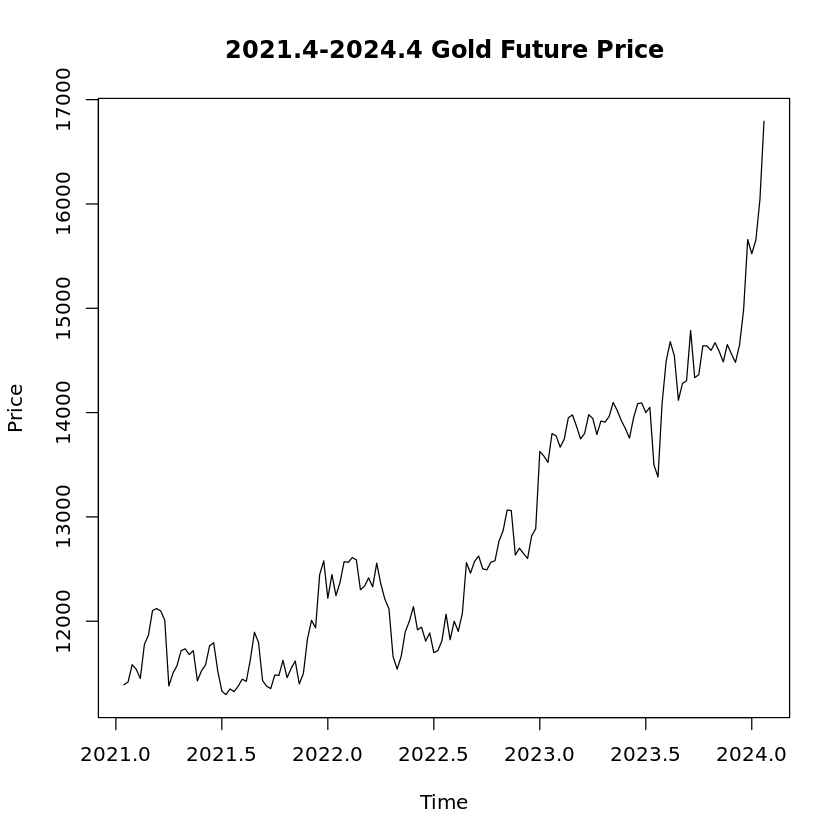

In [4]:
plot(gold.data, type = 'l', main = '2021.4-2024.4 Gold Future Price')

### 2.3 Data analysis

#### Plot the Autocorrelation Function (ACF) for the gold futures price data 
Preliminarily check the stationarity of the data.

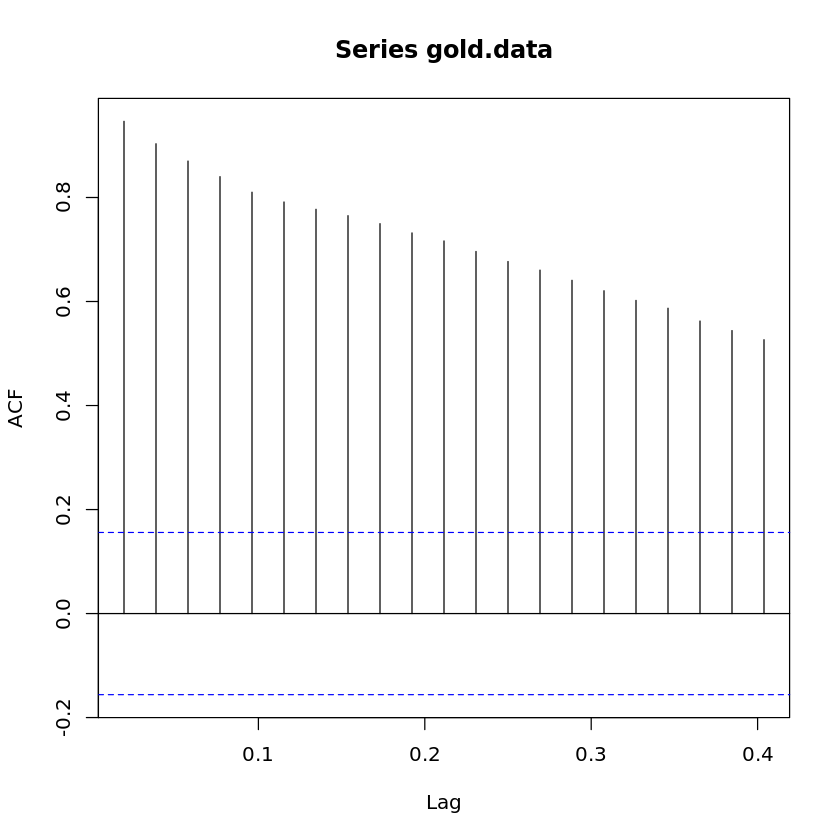

In [5]:
#data analysis 
acf(gold.data)#non-stationary series

Since the ACF plot shows a long correlation structure, it indicates that the data may be non-stationary. Therefore, a logarithmic transformation of the data can be performed.

#### Logarithmic transformation
The log-transformed spot gold price plot shows the trend of prices over time.

$$\log_{}{(G_t)} = Y_t$$

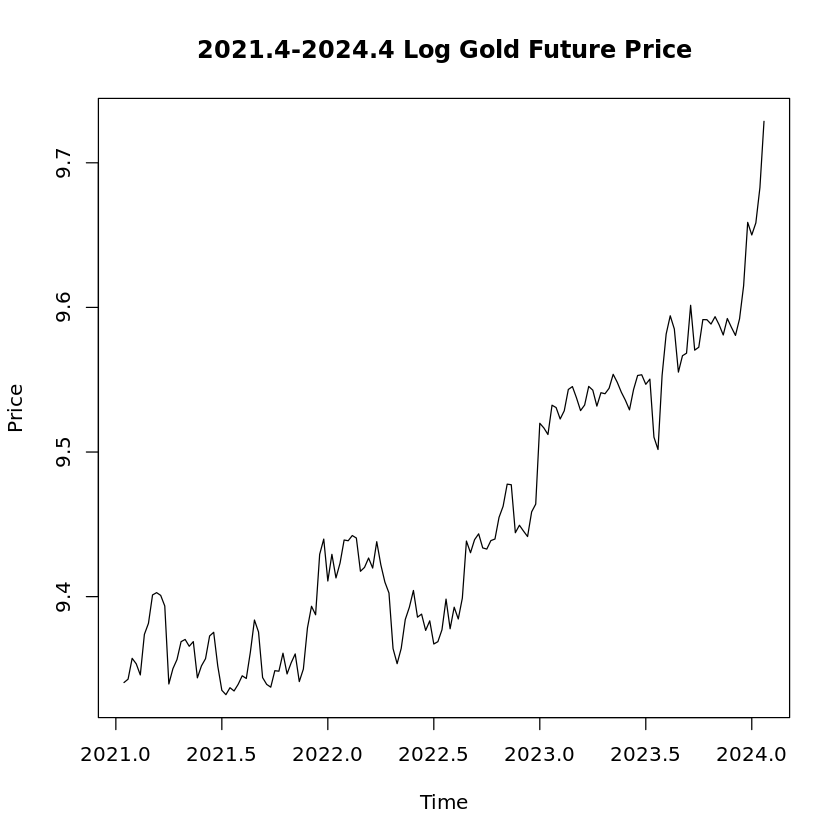

In [6]:
plot(log(gold.data), type = 'l', main = '2021.4-2024.4 Log Gold Future Price')

The log-transformed gold price time series plot shows little change compared to the original data plot, indicating that the logarithmic transformation did not make the price data relatively stationary. Therefore, further data processing is needed.

**Difference judgment**   
Determine the most suitable number of differences for the log-processed data.

In [7]:
ndiffs(log(gold.data))#best diff

[1] 1

The results show that the data need to be first order difference.

#### First order difference equation
$$
\Delta Y_{t} = Y_{t}- Y_{t-1} 
$$ 

**Time sequence diagram of the data after difference**  
Determine whether the differenced data is in a stationary state.

### 2.4 Stationarity test

#### Augmented Dickey-Fuller(ADF)
The Augmented Dickey-Fuller (ADF) test is used to detect whether a time series has a unit root, indicating non-stationarity. 
- $H_0$: There is a unit root (non-stationary).
- $H_1$: There is no unit root (stationary).

The ADF test addresses autocorrelation in the series by including lagged terms in a regression model. If the test statistic is less than the critical value or the p-value is less than the significance level, the null hypothesis is rejected, indicating that the series is stationary.


Title:
 Augmented Dickey-Fuller Unit Root Test

Test Results:


Description:
 Sat May 25 14:24:13 2024 by user: 

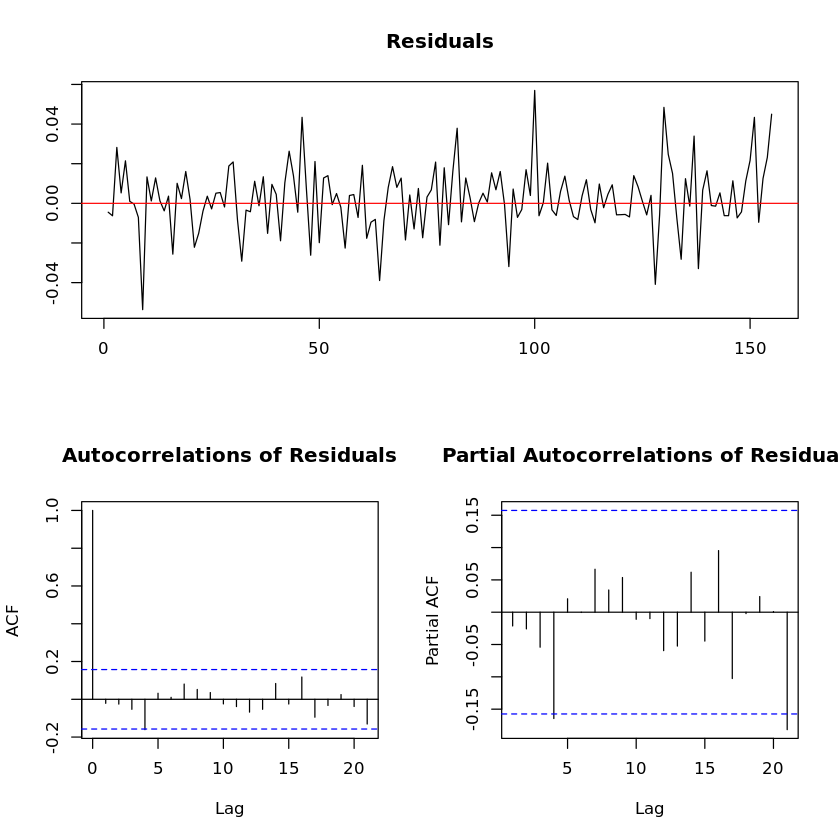

In [8]:
urdfTest(diff(log(gold.data)))

In [9]:
adf.test(diff(log(gold.data)))

Warning message in adf.test(diff(log(gold.data))):
“p-value smaller than printed p-value”


	Augmented Dickey-Fuller Test

data:  diff(log(gold.data))
Dickey-Fuller = -5.5836, Lag order = 5, p-value = 0.01
alternative hypothesis: stationary


Results display :
- Dickey-Fuller = -6.2613
- Lag order = 5
- p-value = 0.01 < 0.05
- Therefore, the null hypothesis is rejected and the sequence is considered stationary

#### Autoregressive Model (AR Model)
A model that describes time series data by assuming that the current value can be explained by past lagged values.

In [10]:
ar(diff(log(gold.data)))


Call:
ar(x = diff(log(gold.data)))


Order selected 0  sigma^2 estimated as  0.0002742

Results display :
- The `ar` function automatically selects the best lag order to fit the AR model and returns the fitting results, including coefficient estimates and lag order.
Data Analysis:
- AR model chooses a fourth-order lag.
- The coefficients of the four lag orders are provided.
- The estimated variance of the residuals is 0.000254.

---

## 3 Trend analysis
### 3.1 Models with time trends

The Cramer decomposition theorem states that any time series $ x_t $ can be decomposed into the sum of two parts:
- One part is the deterministic trend component determined by a polynomial,
- The other part is the stationary zero-mean error component.
$$
x_{t}=\mu_{t}+\epsilon_{t}=\sum_{j=0}^{d} \beta_{j} t^{j}+\Psi(B) a_{t}
$$

The deterministic component can further be divided into a trend factor $ T_t $ and a seasonal factor $ S_t $. Intuitively, our log-price series exhibits a positive long-term linear trend and does not contain any seasonal factors.

### 3.2 Linear regression models with time series errors

#### Regression of logarithm of gold prices on time trend

- Perform a linear regression model on the logarithm of gold prices to analyze the time trend.
- The independent variable is time, and the dependent variable is the logarithm of gold prices.
- Determine if gold prices exhibit a significant trend over time.

In [11]:
#time trend regression
gold.reg <- lm(log(gold.data)~time(log(gold.data)))
summary(gold.reg)


Call:
lm(formula = log(gold.data) ~ time(log(gold.data)))

Residuals:
      Min        1Q    Median        3Q       Max 
-0.081065 -0.025904  0.003704  0.024210  0.128705 

Coefficients:
                       Estimate Std. Error t value Pr(>|t|)    
(Intercept)          -1.878e+02  6.910e+00  -27.18   <2e-16 ***
time(log(gold.data))  9.753e-02  3.417e-03   28.55   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.03767 on 156 degrees of freedom
Multiple R-squared:  0.8393,	Adjusted R-squared:  0.8383 
F-statistic: 814.9 on 1 and 156 DF,  p-value: < 2.2e-16


The regression results provided by R are as follows:

$$
G_{t} = -187.8 + 0.09753 t + e_{t}
$$

Where the adjusted R-squared is 0.8303. Both the slope and intercept parameters are significant, indicating a significant fit.

#### Plotting standardized residuals graph

The standardized residuals plot can be used to check the distribution and patterns of model residuals, to detect any systematic biases.

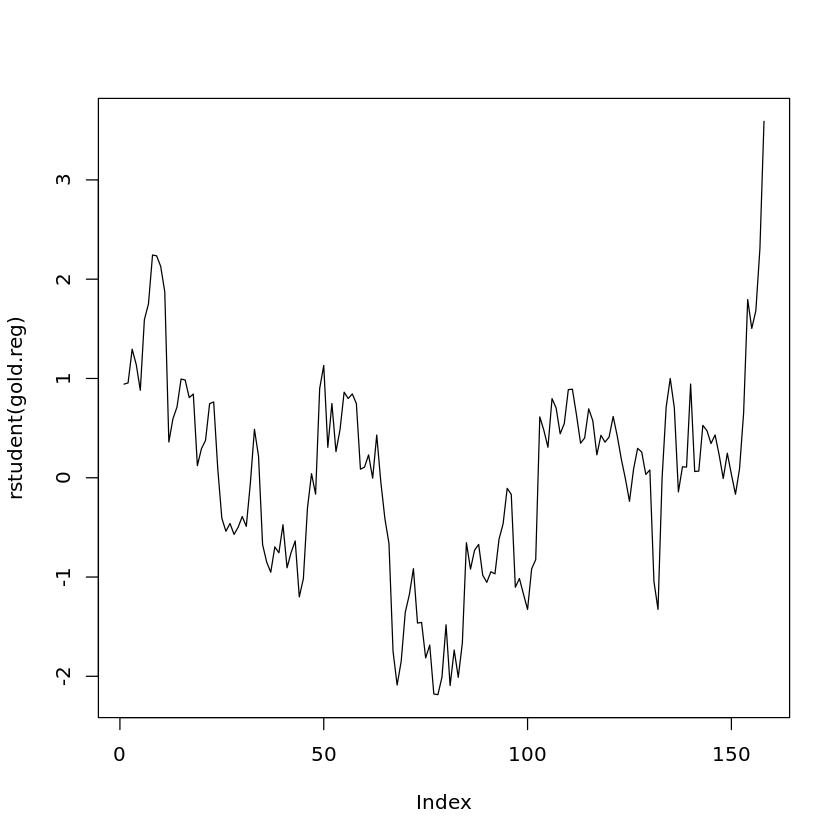

In [12]:
plot(rstudent(gold.reg), type = 'l')

#### Computing the mean of standardized residuals for the regression model

In [13]:
mean(rstandard(gold.reg))

[1] 0.001871396

The mean of these residuals is close to zero, indicating the absence of systematic bias.

#### Plotting the autocorrelation of standardized residuals for regression

Used to detect whether there's significant autocorrelation among residuals.

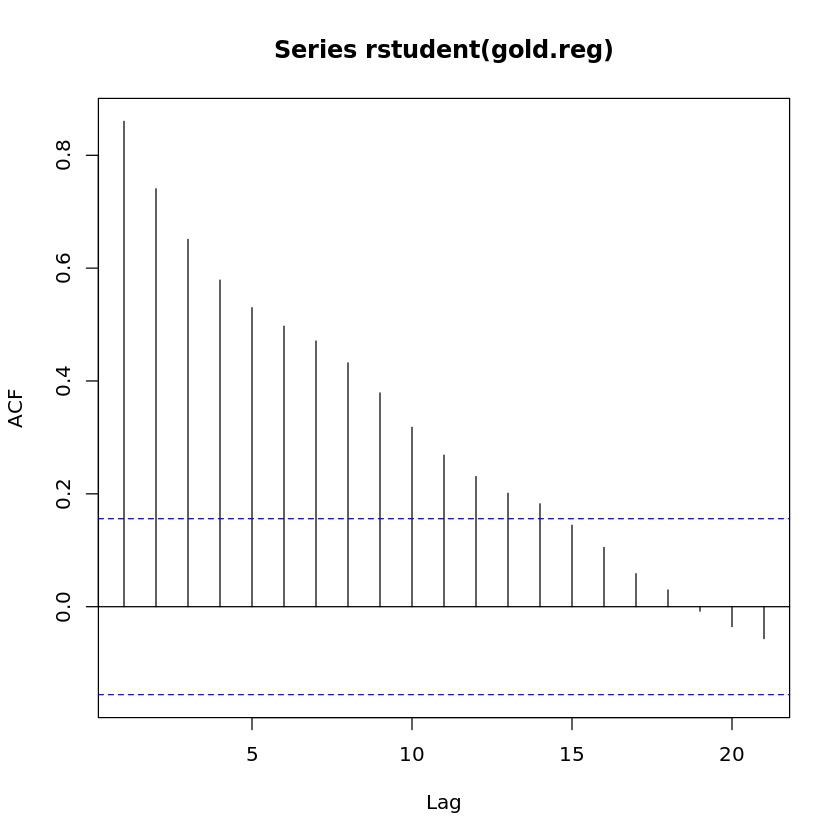

In [14]:
acf(rstudent(gold.reg))

The presence of autocorrelation among residuals suggests that the model might not fully fit the data.

#### Summary

Observing all the results above, it's apparent that the extracted long-term trend is insufficient to render the residuals stationary, indicating a spurious regression, where the trend is likely a random fluctuation. 
Despite the goodness of fit and significance levels, the regression relationship cannot accurately reflect the equilibrium relationship between the dependent and explanatory variables due to the non-stationarity of the residual sequence. 
Instead, it's merely a numerical coincidence.

### 3.3 Trend assessment

 Based on the regression model results, we observe a gradual increase in gold prices over the long term. When time series data exhibit a clear upward or downward trend, models containing a drift term can better capture and describe this trend. Therefore, fitting a non-stationary ARIMA model with a random trend is more appropriate.

---

## 4 Building the ARIMA model

### 4.1 Model identification

#### Autocorrelation function (ACF) plot

The Autocorrelation Function (ACF) is a function used to compute the autocorrelation of a time series with itself.

An ACF plot is a graph where the x-axis represents the lag values (in the above graph, it's lag 1), and the y-axis represents the autocorrelation coefficients (the correlation between $X_{t}$ and $X_{t-1}$).

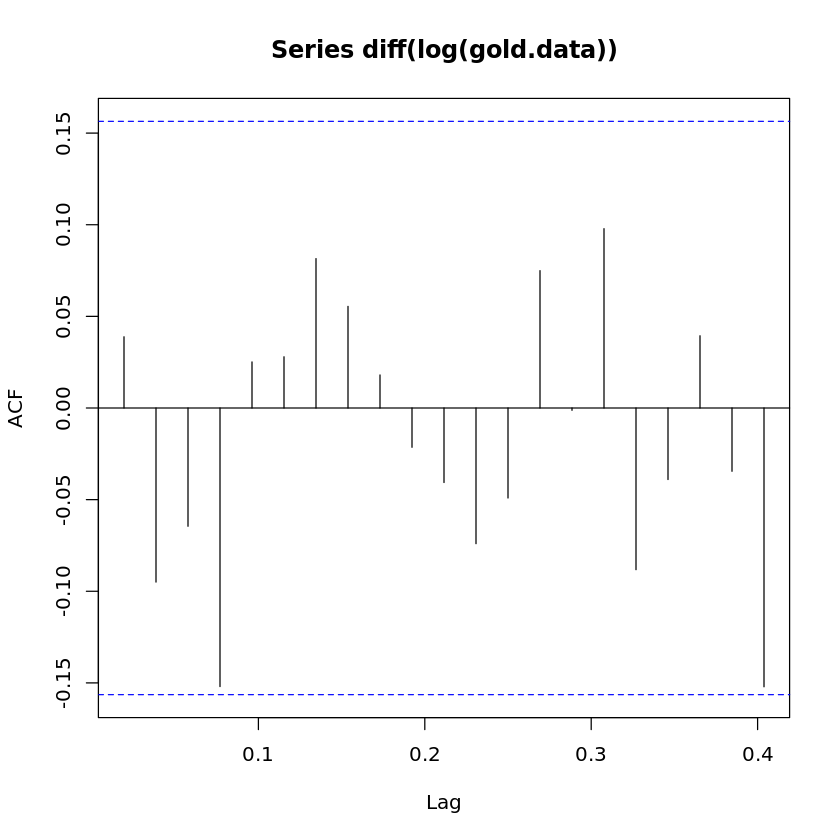

In [15]:
acf(diff(log(gold.data)))

#### Partial autocorrelation function (PACF) plot

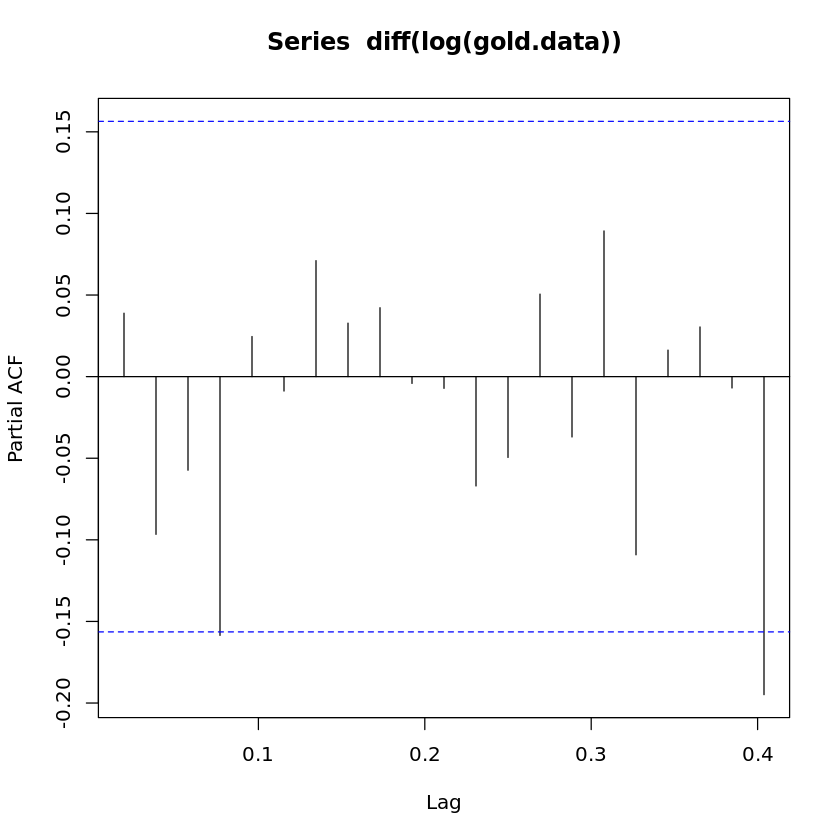

In [16]:
pacf(diff(log(gold.data)))

From both the ACF and PACF plots, there are no clear cutoffs, tails, or features that can be used for model order identification.

#### The extended autocorrelation function (EACF) method

Since identifying ARMA mixed models based on sample ACF and PACF is challenging, using EACF to determine the order is appropriate.

In [17]:
time <- time(gold.data)
eacf(diff(log(gold.data)))

AR/MA
  0 1 2 3 4 5 6 7 8 9 10 11 12 13
0 o o o o o o o o o o o  o  o  o 
1 x o o o o o o o o o o  o  o  o 
2 x x o x o o o o o o o  o  o  o 
3 x x x o o o o o o o o  o  o  o 
4 o o x x o o o o o o o  o  o  o 
5 x o x o o o o o o o o  o  o  o 
6 x x x o o o o o o o o  o  o  o 
7 x x x o o o o o o o o  o  o  o 


The EACF table suggests prioritizing the ARIMA(0,1,0) model, followed by the IMA(1,2) and ARIMA(3,1,3) models.

#### Bayesian information criterion (BIC)

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“11  linear dependencies found”


	One Sample t-test

data:  diff(log(gold.data))
t = 1.8703, df = 156, p-value = 0.06331
alternative hypothesis: true mean is not equal to 0
95 percent confidence interval:
 -0.0001387006  0.0050824521
sample estimates:
  mean of x 
0.002471876 


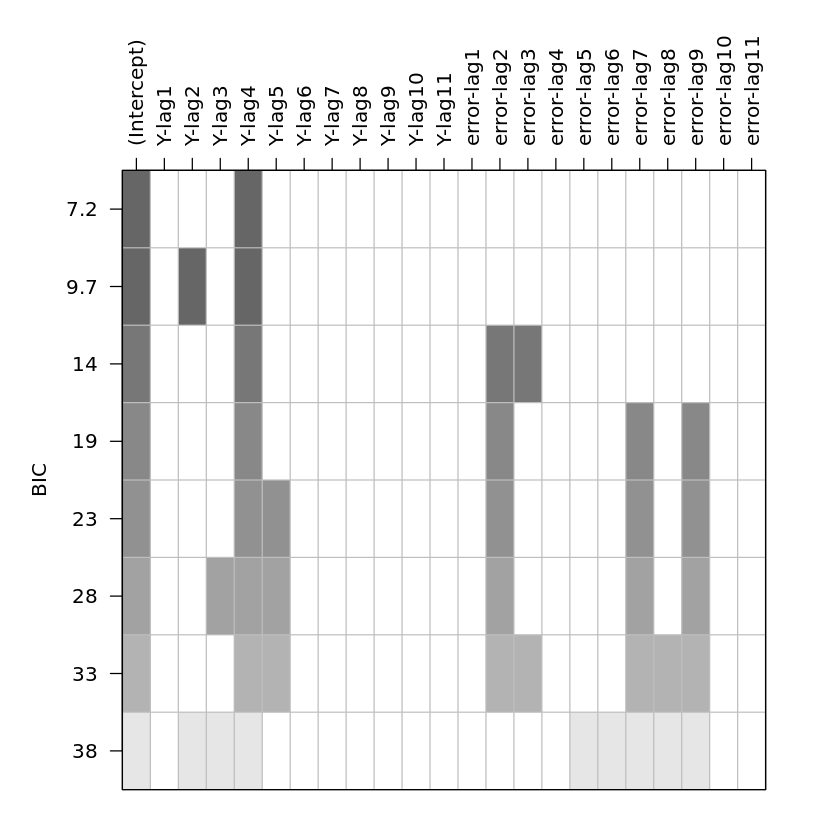

In [18]:
plot(armasubsets(y = diff(log(gold.data)), nar = 11, nma = 11), ar.methods = 'ols')#BIC subsets
mean <- mean(diff(log(gold.data)))
t.test(diff(log(gold.data)))#intercept hard to recognize

The results suggest considering sparse coefficient models with intercept term ARI(4,1), followed by ARI((2,4),1), ARIMA(4,1,2), and ARIMA(4,1,(2,3)).

### 4.2 Model fitting

**Overall consideration**  
ARIMA(0,1,0)，IMA(1,2)，ARIMA(3,1,3)  
ARI(4,1,0)，ARI(2,1,0)，ARIMA(4,1,2)，ARIMA(4,1,3)

**In considering the three model selection criteria, AIC, AICc, and BIC, with 158 data samples falling between small and large sample sizes:**
- **AICc (Corrected Akaike Information Criterion):**
   - **Applicability**: AICc corrects for small sample sizes and gradually approaches AIC as sample size increases.
   - **Advantages**: With a sample size of 158, AICc provides a prudent choice due to its correction for small samples, maintaining good performance even for moderate sample sizes.
- **AIC (Akaike Information Criterion):**
   - **Applicability**: AIC is generally applicable and performs well, especially for larger sample sizes.
   - **Advantages**: AIC can also be an effective choice with 158 samples, though lacking the small sample correction, it might slightly favor overfitting, especially for relatively smaller sample sizes.
- **BIC (Bayesian Information Criterion):**
   - **Applicability**: BIC excels for larger sample sizes, as it imposes a stronger penalty, favoring simpler models.
   - **Advantages**: BIC provides stricter penalties for complex models with increasing sample size, ensuring models do not become overly complex. However, with 158 samples, BIC might overly penalize complex models, potentially leading to overly simplistic model choices.

**Synthesis: Opt for the model with the lowest AICc value, while considering AIC and BIC for validation and reference.**
- **Priority to AICc**: With 158 samples, AICc offers a more robust model selection criterion by correcting for small sample sizes, balancing fit and complexity.
- **Reference to AIC and BIC**: Although AICc is more suitable for this sample size, it's still valuable to compute AIC and BIC as supplementary references. AIC helps confirm model fit, while BIC provides a stricter control on model complexity.

#### Separate fitting

In [19]:
# ARIMA(0,1,0)
Arima(log(gold.data), order=c(0,1,0), include.constant = TRUE, transform.pars = FALSE, method = 'ML')

Series: log(gold.data) 
ARIMA(0,1,0) with drift 

Coefficients:
       drift
      0.0025
s.e.  0.0013

sigma^2 = 0.0002748:  log likelihood = 421.55
AIC=-839.1   AICc=-839.02   BIC=-832.99

In [20]:
# ARIMA(4,1,0)
Arima(log(gold.data), order=c(4,1,0), include.constant = TRUE, transform.pars = FALSE, method = 'ML')

Series: log(gold.data) 
ARIMA(4,1,0) with drift 

Coefficients:
         ar1      ar2      ar3      ar4   drift
      0.0263  -0.1159  -0.0600  -0.1673  0.0024
s.e.  0.0803   0.0806   0.0803   0.0802  0.0010

sigma^2 = 0.0002701:  log likelihood = 424.86
AIC=-837.73   AICc=-837.17   BIC=-819.39

In [21]:
# IMA(1,2)
Arima(log(gold.data), order=c(0,1,2), include.constant = TRUE, transform.pars = FALSE, method = 'ML')

Series: log(gold.data) 
ARIMA(0,1,2) with drift 

Coefficients:
         ma1      ma2   drift
      0.0264  -0.1424  0.0024
s.e.  0.0838   0.0984  0.0012

sigma^2 = 0.0002742:  log likelihood = 422.71
AIC=-837.42   AICc=-837.15   BIC=-825.19

In [22]:
# ARI(2,1,0)
Arima(log(gold.data), order=c(2,1,0), include.constant = TRUE, transform.pars = FALSE, method = 'ML')

Series: log(gold.data) 
ARIMA(2,1,0) with drift 

Coefficients:
         ar1      ar2   drift
      0.0421  -0.1003  0.0024
s.e.  0.0810   0.0813  0.0012

sigma^2 = 0.0002752:  log likelihood = 422.43
AIC=-836.86   AICc=-836.6   BIC=-824.64

In [23]:
# ARIMA(3,1,3) 
Arima(log(gold.data), order=c(3,1,3), include.constant = TRUE, transform.pars = FALSE, method = 'ML')

Series: log(gold.data) 
ARIMA(3,1,3) with drift 

Coefficients:
         ar1     ar2      ar3      ma1      ma2     ma3   drift
      0.6462  0.0687  -0.7427  -0.6376  -0.1772  0.8121  0.0025
s.e.  0.1840  0.2574   0.1826   0.1618   0.2310  0.1603  0.0012

sigma^2 = 0.0002489:  log likelihood = 430.04
AIC=-844.09   AICc=-843.12   BIC=-819.64

In [24]:
# ARIMA(4,1,2)
Arima(log(gold.data), order=c(4,1,2), include.constant = TRUE, transform.pars = FALSE, method = 'ML')

Series: log(gold.data) 
ARIMA(4,1,2) with drift 

Coefficients:
          ar1     ar2      ar3      ar4     ma1      ma2   drift
      -0.2547  0.0584  -0.0969  -0.1659  0.2903  -0.1700  0.0024
s.e.   0.3996  0.3281   0.0975   0.0913  0.4070   0.3341  0.0010

sigma^2 = 0.0002731:  log likelihood = 425.02
AIC=-834.05   AICc=-833.07   BIC=-809.6

In [25]:
# ARI(4,1,3)
Arima(log(gold.data), order=c(4,1,3), include.constant = TRUE, transform.pars = FALSE, method = 'ML')

Series: log(gold.data) 
ARIMA(4,1,3) with drift 

Coefficients:
        ar1      ar2      ar3      ar4      ma1      ma2     ma3   drift
      0.654  -0.0230  -0.6255  -0.0822  -0.6929  -0.0824  0.7501  0.0025
s.e.  0.204   0.3005   0.2349   0.0891   0.1922   0.2856  0.1955  0.0011

sigma^2 = 0.0002491:  log likelihood = 430.45
AIC=-842.91   AICc=-841.68   BIC=-815.4

In [26]:
# ARIMA(4,1,4)
Arima(log(gold.data), order=c(4,1,4), include.constant = TRUE, transform.pars = FALSE, method = 'ML')

Series: log(gold.data) 
ARIMA(4,1,4) with drift 

Coefficients:
          ar1     ar2      ar3      ar4     ma1      ma2     ma3     ma4
      -0.4307  0.6620  -0.5255  -0.9033  0.4516  -0.7850  0.4996  0.9668
s.e.   0.0685  0.0399   0.0383   0.0674  0.0613   0.0468  0.0472  0.0626
       drift
      0.0025
s.e.  0.0012

sigma^2 = 0.0002431:  log likelihood = 432.47
AIC=-844.94   AICc=-843.43   BIC=-814.38

#### Create a loop and find the minimum value

In [27]:
# Set the range of p, d, q
p_range <- 0:5
d_range <- 0:3
q_range <- 0:5

# initialization
best_model_bic <- list(model = NULL, bic = Inf)
best_model_aic <- list(model = NULL, aic = Inf)
best_model_aicc <- list(model = NULL, aicc = Inf)

In [28]:
for (p in p_range) {
  for (d in d_range) {
    for (q in q_range) {
      try({
        # fit
        fit <- Arima(log(gold.data), order = c(p, d, q), include.constant = TRUE, transform.pars = FALSE, method = 'ML')
        
        # BIC 
        if (fit$bic < best_model_bic$bic) {
          best_model_bic$model <- fit
          best_model_bic$bic <- fit$bic
        }
        
        # AIC 
        if (fit$aic < best_model_aic$aic) {
          best_model_aic$model <- fit
          best_model_aic$aic <- fit$aic
        }
        
        # AICc 
        if (fit$aic < best_model_aicc$aicc) {
          best_model_aicc$model <- fit
          best_model_aicc$aicc <- fit$aicc
        }
      }, silent = TRUE)
    }
  }
}


cat("--------------------Best Model by BIC--------------------\n")
summary(best_model_bic$model)
cat("BIC:", best_model_bic$bic, "\n\n")

cat("--------------------Best Model by AIC--------------------\n")
summary(best_model_aic$model)
cat("AIC:", best_model_aic$aic, "\n\n")

cat("--------------------Best Model by AICc-------------------\n")
summary(best_model_aicc$model)
cat("AICc:", best_model_aicc$aicc, "\n")


--------------------Best Model by BIC--------------------


Series: log(gold.data) 
ARIMA(0,1,0) with drift 

Coefficients:
       drift
      0.0025
s.e.  0.0013

sigma^2 = 0.0002748:  log likelihood = 421.55
AIC=-839.1   AICc=-839.02   BIC=-832.99

Training set error measures:
                       ME       RMSE        MAE          MPE      MAPE
Training set 5.910196e-05 0.01647145 0.01204183 0.0002582923 0.1272948
                  MASE       ACF1
Training set 0.1192888 0.03880799

BIC: -832.9875 

--------------------Best Model by AIC--------------------


Series: log(gold.data) 
ARIMA(4,1,4) with drift 

Coefficients:
          ar1     ar2      ar3      ar4     ma1      ma2     ma3     ma4
      -0.4307  0.6620  -0.5255  -0.9033  0.4516  -0.7850  0.4996  0.9668
s.e.   0.0685  0.0399   0.0383   0.0674  0.0613   0.0468  0.0472  0.0626
       drift
      0.0025
s.e.  0.0012

sigma^2 = 0.0002431:  log likelihood = 432.47
AIC=-844.94   AICc=-843.43   BIC=-814.38

Training set error measures:
                      ME       RMSE       MAE          MPE      MAPE      MASE
Training set -1.1364e-05 0.01509092 0.0110919 -0.000470121 0.1172533 0.1098787
                    ACF1
Training set -0.02568396

AIC: -844.939 

--------------------Best Model by AICc-------------------


Series: log(gold.data) 
ARIMA(4,1,4) with drift 

Coefficients:
          ar1     ar2      ar3      ar4     ma1      ma2     ma3     ma4
      -0.4307  0.6620  -0.5255  -0.9033  0.4516  -0.7850  0.4996  0.9668
s.e.   0.0685  0.0399   0.0383   0.0674  0.0613   0.0468  0.0472  0.0626
       drift
      0.0025
s.e.  0.0012

sigma^2 = 0.0002431:  log likelihood = 432.47
AIC=-844.94   AICc=-843.43   BIC=-814.38

Training set error measures:
                      ME       RMSE       MAE          MPE      MAPE      MASE
Training set -1.1364e-05 0.01509092 0.0110919 -0.000470121 0.1172533 0.1098787
                    ACF1
Training set -0.02568396

AICc: -843.4321 


Based on the above results, ARIMA(4,1,4) is selected.

**Assessing the significance of parameters in the ARIMA(4,1,4) model**

Comparing the quotient obtained by dividing the estimated coefficients by their standard errors (se) with the critical value of the T statistic at $5%$ significance level ($1.96$), if the absolute value of the quotient is greater than $1.96$, we reject the null hypothesis and consider the coefficient to be statistically significant. Otherwise, if the absolute value of the quotient is less than or equal to $1.96$, we consider the coefficient to be not statistically significant.

In [29]:
-0.4307/0.0685
0.6620/0.0399
-0.5255/0.0383
-0.9033/0.0674
0.4516/0.0613
-0.7850/0.0468  
0.4996/0.0472  
0.9668/0.0626

[1] -6.287591

[1] 16.59148

[1] -13.72063

[1] -13.40208

[1] 7.367047

[1] -16.7735

[1] 10.58475

[1] 15.44409

Upon calculation, all coefficients are found to be statistically significant, not equal to zero.

### 4.3 Deriving the final ARIMA model
### Mathematical Expression of the ARIMA(4,1,4) Model

The ARIMA(4,1,4) model consists of three parts: the autoregressive (AR) part, the differencing (I) part, and the moving average (MA) part.

#### General Form

First, let's define some symbols:
  - $  Y_t$ is the value of the time series data at time $t$. 
  - $  \Delta Y_t$ is the differencing term.  
  - $  \phi_i$ is the autoregressive coefficient.   
  - $  \theta_i$ is the moving average coefficient.   
  - $  \epsilon_t$ is the error term (white noise) at time \(t\).   
  - $  c$ is the drift term.  

For an ARIMA(4,1,4) model:

1. Differencing (I) part:
   - The model has  $d = 1$, indicating first-order differencing:
     $
     \Delta Y_t = Y_t - Y_{t-1}
     $

2. Autoregressive (AR) part:
   - The order of the autoregressive part is $p = 4$:
     $
     \Delta Y_t = c + \phi_1 \Delta Y_{t-1} + \phi_2 \Delta Y_{t-2} + \phi_3 \Delta Y_{t-3} + \phi_4 \Delta Y_{t-4} + \epsilon_t
     $

3. Moving Average (MA) part:
   - The order of the moving average part is $q = 4$:
     $
     \epsilon_t = \theta_1 \epsilon_{t-1} + \theta_2 \epsilon_{t-2} + \theta_3 \epsilon_{t-3} + \theta_4 \epsilon_{t-4}
     $

#### Combined Model

Combining the autoregressive and moving average parts, we can express the complete mathematical expression of the ARIMA(4,1,4) model as:
$$
\Delta Y_t = c + \phi_1 \Delta Y_{t-1} + \phi_2 \Delta Y_{t-2} + \phi_3 \Delta Y_{t-3} + \phi_4 \Delta Y_{t-4} + \epsilon_t + \theta_1 \epsilon_{t-1} + \theta_2 \epsilon_{t-2} + \theta_3 \epsilon_{t-3} + \theta_4 \epsilon_{t-4}
$$

Expressing it in terms of $ Y_t $ and $ Y_{t-1} $, we get:
$$
Y_t - Y_{t-1} = c + \phi_1 (Y_{t-1} - Y_{t-2}) + \phi_2 (Y_{t-2} - Y_{t-3}) + \phi_3 (Y_{t-3} - Y_{t-4}) + \phi_4 (Y_{t-4} - Y_{t-5}) + \epsilon_t + \theta_1 \epsilon_{t-1} + \theta_2 \epsilon_{t-2} + \theta_3 \epsilon_{t-3} + \theta_4 \epsilon_{t-4}
$$

Rearranging, we have:
$$
Y_t = c + (\phi_1 + 1) Y_{t-1} + (\phi_2 - \phi_1) Y_{t-2} + (\phi_3 - \phi_2) Y_{t-3} + (\phi_4 - \phi_3) Y_{t-4} + \phi_4 Y_{t-5}  + \epsilon_t + \theta_1 \epsilon_{t-1} + \theta_2 \epsilon_{t-2} + \theta_3 \epsilon_{t-3} + \theta_4 \epsilon_{t-4}
$$

Substituting the calculated coefficients:
$$ Y_t = 0.0025 + 0.5693 Y_{t-1} - 0.2313 Y_{t-2} - 1.1875 Y_{t-3} - 0.3778 Y_{t-4} - 0.9033 Y_{t-5} + \epsilon_t + 0.4516 \epsilon_{t-1} - 0.7850 \epsilon_{t-2} + 0.4996 \epsilon_{t-3} + 0.9668 \epsilon_{t-4}
$$

Given:
$$ \log{(G_t)} = Y_t $$

We finally have:
$$ G_t = e^{0.0025 + 0.5693 Y_{t-1} - 0.2313 Y_{t-2} - 1.1875 Y_{t-3} - 0.3778 Y_{t-4} - 0.9033 Y_{t-5} + \epsilon_t + 0.4516 \epsilon_{t-1} - 0.7850 \epsilon_{t-2} + 0.4996 \epsilon_{t-3} + 0.9668 \epsilon_{t-4}} 
$$

#### Summary

The ARIMA(4,1,4) model applies first-order differencing to the time series data, then models the result as a mixed model containing 4 autoregressive terms and 4 moving average terms. Its specific form is as shown above, indicating that the differenced data is a linear combination of the previous differenced data and its error terms.

In [30]:
model <- Arima(log(gold.data), order = c(4,1,4), include.constant = TRUE, transform.pars = FALSE, method = 'ML')

---

## 5 Model diagnosis

By conducting a comprehensive diagnostic analysis of the residuals from the ARIMA model, this study aims to evaluate the effectiveness and applicability of the model, providing guidance for further model improvements.

### 5.1 Standardized residual plot

#### Standardized residuals($r_{i}$)
$$r_{i}=\frac{e_{i}}{S_{e}}=\frac{Y_{i}-\hat{Y_{i}}}{S_{e}}$$
- ${S_{e}}$: Estimate of the standard deviation of residuals

This plot is an important graphical tool used to help assess the quality of fit of a regression model and whether assumptions are met.

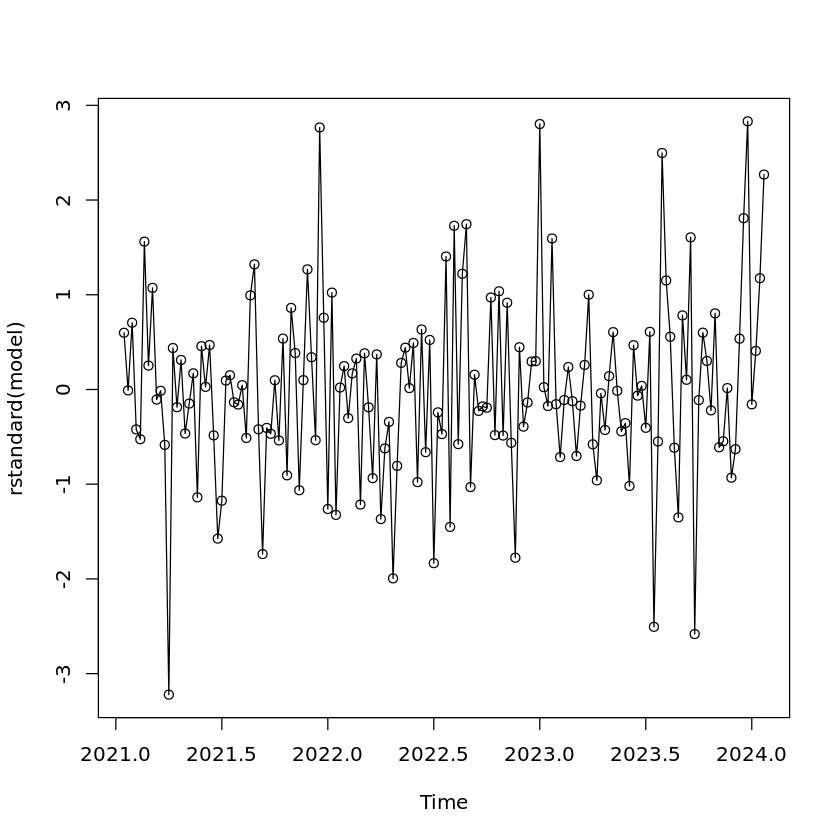

In [31]:
plot(rstandard(model), type = 'o')

- **Testing for homoscedasticity of error variance:** The residual plot does not exhibit any clear patterns, indicating our initial assessment that the variance of residuals does not change with increasing predicted values, meaning the residuals do not exhibit heteroscedasticity.

- **Testing for independence of residuals:** By observing the distribution of residuals in the standardized residual plot, there is no indication of any major irregularities in the model.

- **Identifying outliers:** There are some outliers in the plot, which could be due to sudden events in the data or limitations of ARIMA; however, we will not discuss them here.

- **Assessing model fit:** The distribution of standardized residuals around the horizontal line indicates that the model fits well.

In general, the model fits reasonably well, but the autocorrelation of residuals still needs to be examined, which will be addressed in the next step.

### 5.2 Quantile-Quantile plot
By observing whether the data points in the Q-Q plot approximate a straight line, it is used to assess whether the residual sequence conforms to the assumption of normal distribution. If so, it is considered that the residual sequence follows a normal distribution; otherwise, it does not conform.

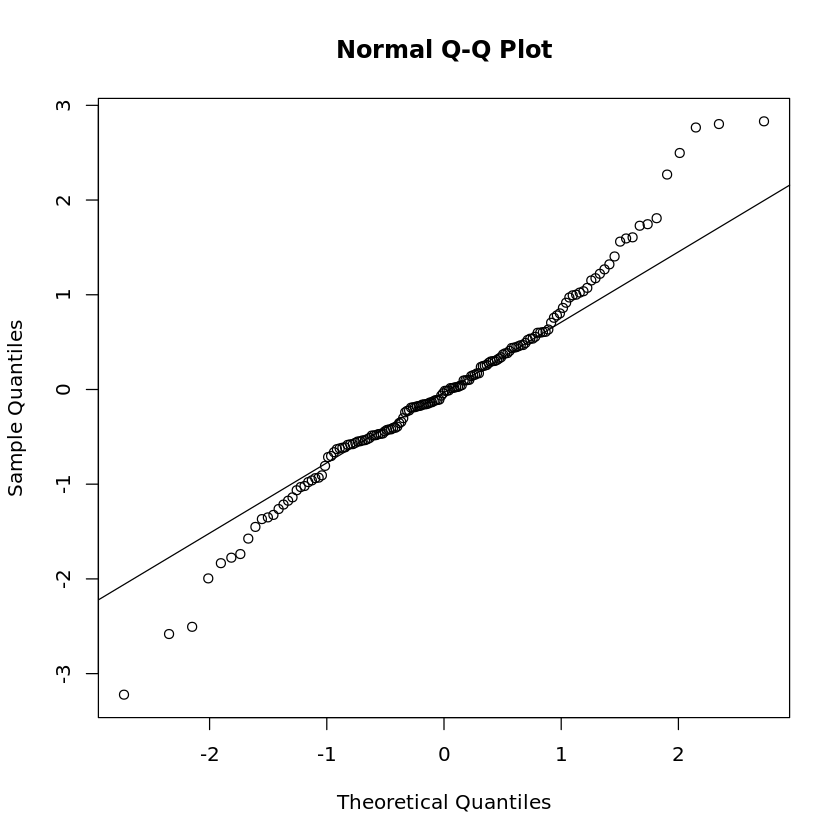

In [32]:
qqnorm(rstandard(model))
qqline(rstandard(model))

We observed significant outliers in the Q-Q plot of residuals from the ARIMA(3,1,3) model of the log gold price series. This indicates that the model is inadequate in some instances, unable to explain the fluctuations in the data effectively. This suggests that further model optimization is needed, considering additional factors or adjusting the model structure to better fit the data.

### 5.3 Probability density plot
By comparing the density estimate of residuals with a standard normal distribution, we can assess whether the residuals adhere to the assumption of a normal distribution.

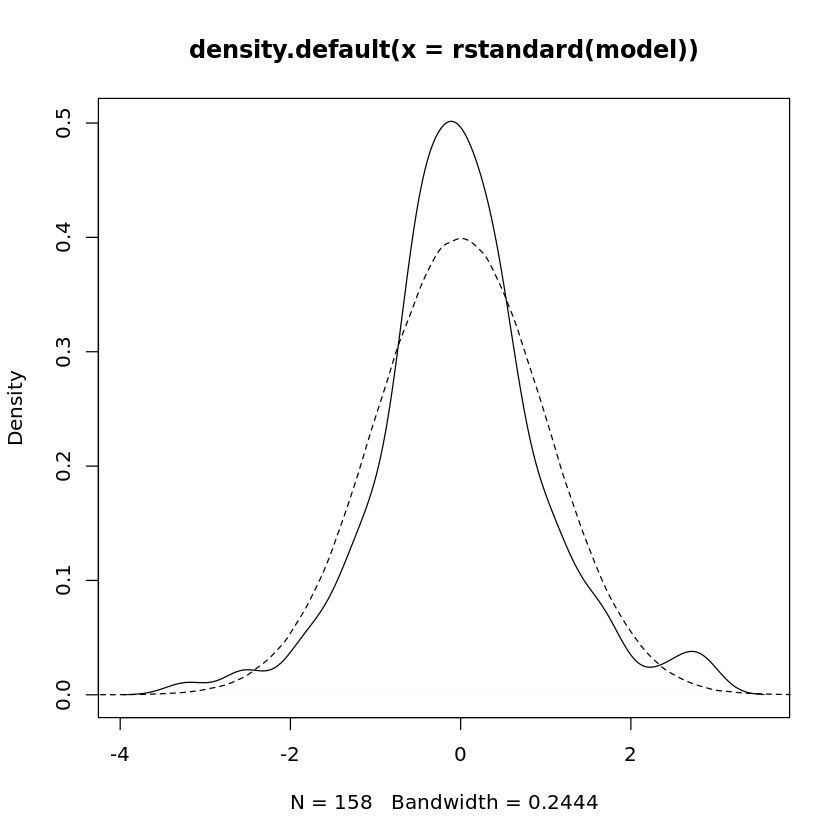

In [33]:
plot(density(rstandard(model)))#sharp and thick
lines(density(rnorm(1000000)), lty = 2) 

We observe a straight segment in the middle of the plot with larger curvatures at the ends, and it does not form a 45-degree angle, indicating that the residuals are likely not normally distributed. From the probability density plot, we can see that compared to a normal distribution, the residual distribution is leptokurtic and fat-tailed, with more outliers.

**Since Q-Q plots and probability density plots can only provide a rough assessment, we will further use statistical tests to examine the normality of the residuals.**

### 5.4 Shapiro-Wilk normality test
The Shapiro-Wilk test is a method used in frequency-based statistical tests to examine normality.

- $H_0:$The sample conforms to a normal distribution.

- $H_1:$The sample does not conform to a normal distribution.

In [34]:
shapiro.test(rstandard(model))


	Shapiro-Wilk normality test

data:  rstandard(model)
W = 0.9744, p-value = 0.004899


$p-value\leqslant 0.05$, this means that we need to reject the null hypothesis, indicating that the standard deviation of the residuals does not follow a normal distribution.

**Heavy-tailed distributions are a common phenomenon in financial data, differing from normal distributions. In these distributions, the probability of extreme values in the tails is higher than in a normal distribution. This means that the probability of extreme values occurring in this data is greater than in normal distribution data. This can impact our previous maximum likelihood estimates, and we will further discuss this issue in the context of model shortcomings and improvements.**

### 5.5 Ljung-Box test
This is a commonly used test for autocorrelation in the error term sequence, which can be used to check if the residuals of a time series model exhibit autocorrelation.

- $H_0:$The sample exhibits autocorrelation and is white noise.

- $H_1:$The sample does not exhibit autocorrelation and is not white noise.

In [35]:
Box.test(rstandard(model), type = "Ljung-Box", lag = log(length(gold.data)))#autocorrelation test


	Box-Ljung test

data:  rstandard(model)
X-squared = 0.29363, df = 5.0626, p-value = 0.998


$p-value\geqslant 0.05 $, this means that we cannot reject the null hypothesis, indicating that there is autocorrelation in the residuals, making it a white noise sequence. This suggests that the model fits well.

### 5.6 Time series diagnosis
Diagnosis is conducted through the sequence plot of standardized residuals, sample ACF of residuals, and the P-values of Ljung-Box test statistics for K from 1 to 10.

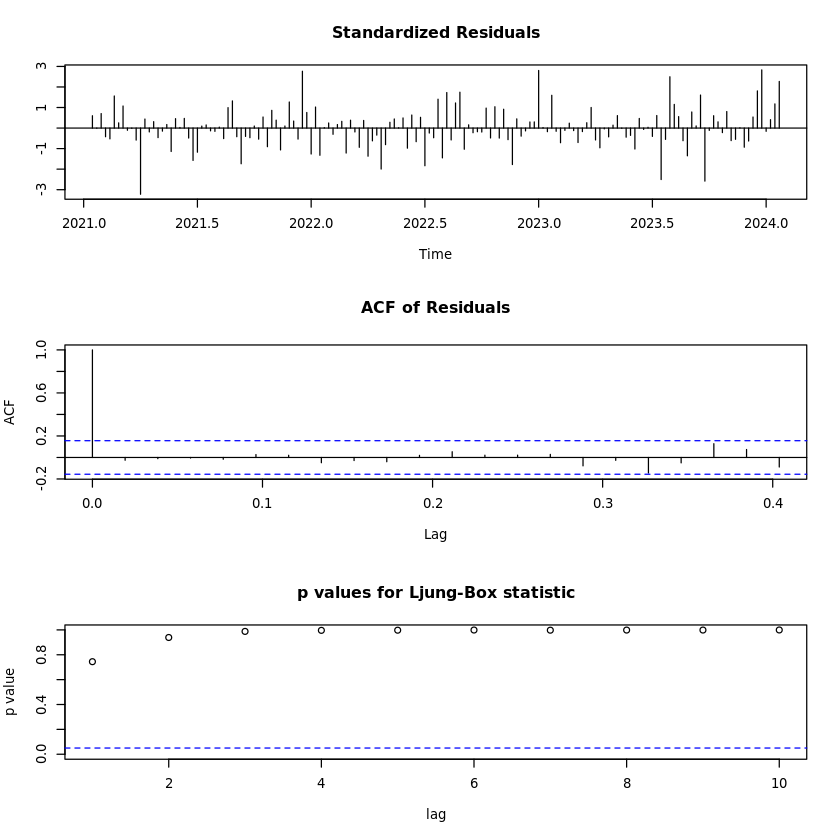

In [36]:
tsdiag(model,gof = 10, omit.initial = F)

Overall, despite the evident autocorrelation in the residuals, indicating that the model effectively captures the time-related information in the original sequence, there are numerous outliers and the residuals' distribution deviates from normality. These factors contribute to the model's less-than-satisfactory fit in certain instances, necessitating further optimization and improvement to enhance overall predictive performance.

---

## 6 Model prediction

### 6.1 Calculation of predicted values

Forecasting time series data of gold prices after taking the logarithm transformation and differencing.

In [41]:
summary(forecast(model, h = 4))


Forecast method: ARIMA(4,1,4) with drift

Model Information:
Series: log(gold.data) 
ARIMA(4,1,4) with drift 

Coefficients:
          ar1     ar2      ar3      ar4     ma1      ma2     ma3     ma4
      -0.4307  0.6620  -0.5255  -0.9033  0.4516  -0.7850  0.4996  0.9668
s.e.   0.0685  0.0399   0.0383   0.0674  0.0613   0.0468  0.0472  0.0626
       drift
      0.0025
s.e.  0.0012

sigma^2 = 0.0002431:  log likelihood = 432.47
AIC=-844.94   AICc=-843.43   BIC=-814.38

Error measures:
                      ME       RMSE       MAE          MPE      MAPE      MASE
Training set -1.1364e-05 0.01509092 0.0110919 -0.000470121 0.1172533 0.1098787
                    ACF1
Training set -0.02568396

Forecasts:
         Point Forecast    Lo 80    Hi 80    Lo 95    Hi 95
2024.077       9.736856 9.716758 9.756955 9.706118 9.767594
2024.096       9.736075 9.707236 9.764914 9.691970 9.780180
2024.115       9.736121 9.702101 9.770141 9.684092 9.788150
2024.135       9.729450 9.690594 9.768305 9.670026 

The model forecasts for the next four weeks for the log-transformed gold prices are 9.736856, 9.736075, 9.736121, 9.729450.
Since we performed a non-linear logarithmic transformation on the original series as $Y_{t} = \log_{}{( G_t)} $, we still need to compute the predicted $\hat G_{t}$ values.

In [38]:
exp (9.736856)
exp (9.736075)
exp (9.736121)
exp (9.729450)

[1] 16930.23

[1] 16917.01

[1] 16917.79

[1] 16805.31

#### Presenting the results

| Date | 2024/4/12  |	2024/4/19 |2024/4/26 |2024/5/3|
|:--------| :--------:|--------:|--------:|--------:|
| $\hat G_{t}$ | 16930.23 |16917.01|16917.79|16805.31|


The calculated predictions for the gold prices for the next four weeks are as follows: $16,930.23 ￥/oz.av$, $16,917.01 ￥/oz.av$, $16,917.79 ￥/oz.av$, $16,805.31 ￥/oz.av$.
Therefore, it can be observed that the gold prices are predicted to decrease over the next four weeks.

### 6.2 Prediction results plot
Visualizing the prediction results of the time series model, plotting a trend graph showing the predicted values over time. This kind of visualization helps in intuitively understanding the predictive performance of the model, observing the trend of predicted values, and gaining a visual understanding of the future data trends.

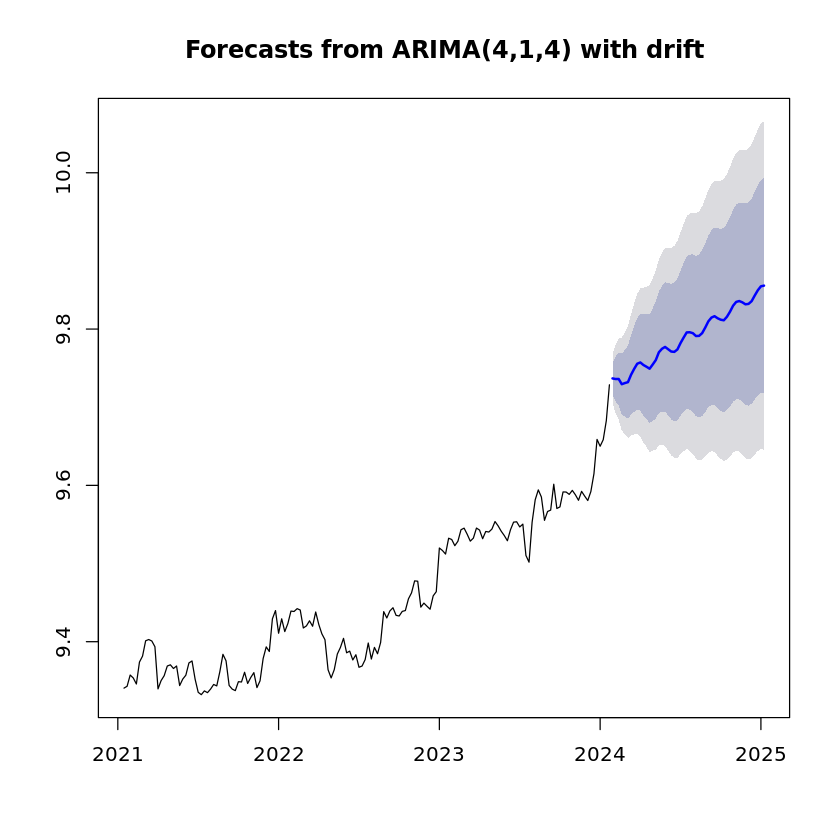

In [39]:
plot(forecast(model, h = 50), main = 'Forecasts from ARIMA(4,1,4) with drift')

Through the ARIMA (4,1,4) model for predicting future gold prices, we believe that in the short term, the gold price will slightly decrease, while in the long term, it will show a trend of increasing volatility.

---

## 7 Conculsion

### 7.1 Summary

This paper applies time series analysis to the annual data series of gold prices in China for a randomness analysis. It also uses the ARIMA model for a small-scale forecast of China's spot gold prices. Through model identification, comparison, and testing, the ARIMA(4,1,4) model is ultimately selected:
 
$$
G_t = e^{0.0025 + 0.5693 Y_{t-1} - 0.2313 Y_{t-2} - 1.1875 Y_{t-3} - 0.3778 Y_{t-4} - 0.9033 Y_{t-5} + \epsilon_t + 0.4516 \epsilon_{t-1} - 0.7850 \epsilon_{t-2} + 0.4996 \epsilon_{t-3} + 0.9668 \epsilon_{t-4}}
$$

Make predictions for the Chinese gold price in April-May 2024 and compare them with the actual values:

|Date | 2024/4/12  |	2024/4/19 |2024/4/26 |2024/5/3|
|:--------| :--------:|--------:|--------:|--------:|
| $\hat G_{t}$ | 16930.23 |16917.01|16917.79|16805.31|
| $G_{t}$ | 16924.5 |17294.84|16914.62|16666.21|

From the analysis and prediction results of the randomness analysis method in this paper, it can be seen that processing the data by taking logarithms, followed by appropriate differencing and selecting appropriate lower model orders, can achieve relatively ideal prediction results.  

The satisfactory fitting results obtained from this paper indicate that the short-term forecast accuracy of time series is relatively high. It can be seen that time series forecasting is an important prediction method with relatively simple models and relatively simple data requirements, only requiring the historical data of the variables themselves, and has wide applicability in practice. In application, the relatively optimal model should be selected based on factors such as the nature of the problem and its characteristics. Gold is an important precious metal whose price fluctuations are influenced by various factors such as the global economy, politics, and financial markets. Such a complex process is not determined by a simple variable or variables, but by a variety of factors. For example, establishing a correlation regression between gold prices and the internationally used currency, the US dollar, can introduce a certain trend-related transformation, or introduce other time series models in addition to the ARIMA model to comprehensively address the gold price issue. Therefore, there are still many shortcomings in this paper, which will be continuously improved in future learning and work.

### 7.2 Model improvement

- **Introducing external factors**: Establishing a correlation regression between the gold price and the widely used international currency, the US dollar, to introduce a certain trend correlation transformation. Alternatively, integrating other time series models besides ARIMA to comprehensively address the gold price issue.

- **Adjusting model complexity**: Considering that the gold price is influenced by multiple factors, trying more complex models, such as extensions of the ARIMA model or combining with other models, to better capture the complexity of gold price fluctuations. For example, combining GARCH with the ARIMA model to verify the gold price.

- **Model ensemble**: Using model ensemble methods, such as Bagging, Boosting, etc., to combine the forecasting results of multiple models to improve overall forecasting performance.

The study still has many shortcomings, but it is hoped that by adopting the above improvement methods, the model fit and prediction accuracy can be enhanced.

---

## References

Cao, Z., & Li, H. (2015). Time Series Model of Gold Daily Trading Prices Based on Intervention Analysis. *Practice and Understanding of  Mathematics*, (15), 146-153.

Luo, Z. (2013). Research on the Trend of Gold Price Based on ARIMA-GARCH Model. *China Foreign Capital*, (06), 31-32.

Xie, N. (2024). Application of time series models in economic analysis: Analysis and prediction of Shaanxi Province GDP. *China-Arab Science and Technology Forum (Chinese and English)*, (02), 42-46.

Yang, Y., Tian, D., Zhang, B., Liu, J., Yang, Z., & Huang, W. (2023). Research on urban economy and population forecasting based on ARIMA model. *Comprehensive Transportation*, (11), 79-85, 97.

---